In [1]:
import DBNets
from DBNets import DBNets2
from DBNets import preproc as pp

#### Open fargo output and generate synthetic observation as done for constructing DBNets2.0 training dataset
As is the function assumes some values for several parameters according to what done for constructing DBNets2.0 training dataset. Check Ruzza et al. (2024) for details.

In [2]:
#We will use this function
pp.fargo_density_to_intensity_standard?

Signature:
pp.fargo_density_to_intensity_standard(
    filename,
    ntheta,
    nr,
    rin,
    rout,
    h0,
    fi,
    St,
    sigma_slope,
    ylog=True,
)
Docstring: <no docstring>
File:      ~/Desktop/DBNets2.0/DBNets/src/DBNets/preproc.py
Type:      function

The code below is to then assume that the planet is at r=1 in code units.

If want to assume differently, for example to make the code focus on a different gap, 
divide rin and rout for the assumed planet position in cu.

The code does that already, just change the `planet_position` variable.

In [15]:
planet_position = 1
image = pp.fargo_density_to_intensity_standard(
                '../../out_00000/dust1dens30.dat',
                    991, #ntheta 
                    319,  #nr
                    0.4/planet_position, #rin in cu
                    3/planet_position, #rout in cu
                    0.031715, #aspect ratio at rp
                    0.25847, #flaring index
                    377.572190925416**-1, #stokes number
                    1.01695 # slope of initial density profile
                    )
# the image must be standardized
image = (image-image.mean())/image.std()

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

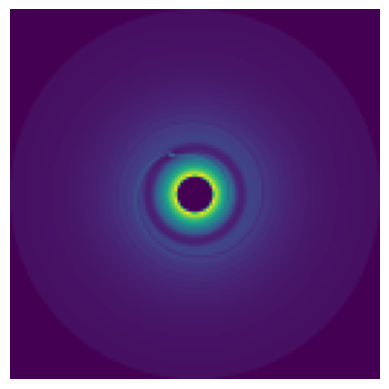

In [16]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.axis('off')

#### Run the inference with DBNets

In [17]:
# this loads the models
dbnets = DBNets2()

In [18]:
# Note, the below code is assuming no gaussian smoothing of the synthetic image
samples, cs = dbnets(image, [0], nsamples=50000)

10105it [00:00, 34723.99it/s]                           
10100it [00:00, 40640.26it/s]                           
10157it [00:00, 40729.50it/s]                           
100%|██████████| 9739/9739 [00:00<00:00, 41128.91it/s]
10100it [00:00, 40651.22it/s]                           

loading all data and parameters
Sample 10 estimates from the posteriror distribution
Interpolating 10 best estimates
Standardize data
FFT
done.
 Compute metric..
DONE!


The method returns `nsamples` samples from the inferred posterior.

These are returned in an array we the following shape: (ninputs, nsamples, 4).

__The last dimension corresponds to the 4 inferred properties in the following order: Alpha, AspectRatio, Stokes, Planet to Star mass ratio__.

The second output cs contains the confidence scores.

In [19]:
samples.shape

(1, 50000, 4)

In [20]:
import numpy as np
labels = ['Alpha', 'AspectRatio', 'Stokes', 'Planet/Star mass ratio']
results_dict = {lab: arr for lab, arr in zip(labels, np.median(samples,axis=1).T)}
results_dict

{'Alpha': array([0.00573748]),
 'AspectRatio': array([0.03592152]),
 'Stokes': array([0.00243279]),
 'Planet/Star mass ratio': array([0.0001552])}